## Protein complex prediction algorithm

In [3]:
import numpy as np
import pandas as pd
import networkx as nx

In [12]:
# Read the eigenvalues of the PPI

Lam = np.loadtxt("eigenvaluestxt_physical.txt")
print(len(Lam))

18063


In [13]:
# Read the eigenvectors of the PPI

M_V = np.loadtxt("eigenvectorstxt_physical.txt", dtype=np.float64)

In [14]:
# Compute inverse participation raito (IPR)

IPR = np.sum(M_V**4, axis=0)

In [9]:
print(min(IPR))

0.00018699866611277663


In [10]:
print(max(IPR))

0.4999999999999998


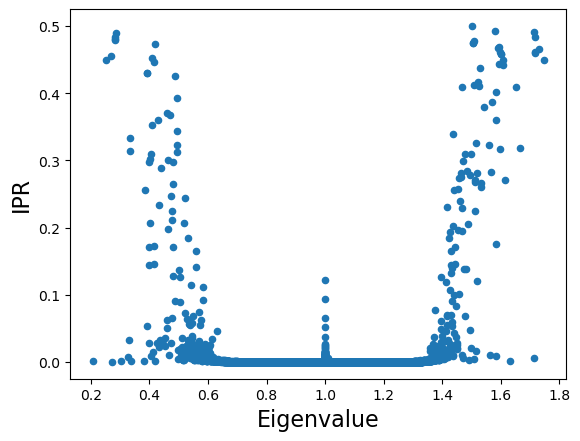

In [23]:
# Plot IPRs

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(Lam, IPR, s=20)
plt.xlabel("Eigenvalue", fontsize = 16)
plt.ylabel("IPR", fontsize = 16)
plt.savefig("Eigvect_IPR.pdf")
plt.show()

In [21]:
# Sort by IPR

idx = idx[np.argsort(IPR[idx])[::-1]]

In [33]:
# Compute number of highly localized eigenvectors

threshold1 = np.percentile(IPR, 95)
threshold2 = np.percentile(IPR, 99)

count1 = np.sum(IPR >= threshold1)
print("Number of highly localized eigenvectors (top 5%):", count1)

count2 = np.sum(IPR >= threshold2)
print("Number of highly localized eigenvectors (top 1%):", count2)

Number of highly localized eigenvectors (top 5%): 904
Number of highly localized eigenvectors (top 1%): 181


In [12]:
# Read the PPI network

path = 'data/'
G_ppi = nx.read_edgelist(path + 'PPI_physical_elist.csv',data=False, delimiter=',')

lcc = max(nx.connected_components(G_ppi), key=len)
G = nx.subgraph(G_ppi,lcc)



# Ensure consistent node mapping

node_list = list(G.nodes())
node_to_idx = {node: i for i, node in enumerate(node_list)}
idx_to_node = {i: node for node, i in node_to_idx.items()}

In [28]:
# Compute dictionary with the clustering coefficient of each node

clustering_dict = nx.clustering(G)

In [137]:
# Main algortihm for predicting complexes



# Compute score of node (localization * clustering coeff)

def compute_scores(G, v, idx_to_node):
    scores = np.zeros_like(v)

    for idx in range(len(v)):
        node = idx_to_node[idx]
        density = clustering_dict[node]
        scores[idx] = (v[idx] ** 2) * density

    return scores




# Iterative expansion

def greedy_local_walk(G, v, idx_to_node, node_to_idx,
                      mass_threshold=0.8,
                      max_nodes=200):

    scores = compute_scores(G, v, idx_to_node)

    # normalize scores so they sum up to 1
    total_mass = np.sum(scores)
    if total_mass == 0:
        return []

    scores = scores / total_mass

    # start from node with highest score
    start_idx = int(np.argmax(scores))
    current_node = idx_to_node[start_idx]

    path = [current_node]
    visited = set([current_node])

    accumulated_mass = scores[start_idx]

    while True:

        # collect neighbors
        frontier = set()
        for u in path:
            for w in G.neighbors(u):
                if w not in visited:
                    frontier.add(w)

        if not frontier:
            break

        # choose node with highest score
        best_node = max(frontier, key=lambda x: scores[node_to_idx[x]])
        best_score = scores[node_to_idx[best_node]]

        # add node
        path.append(best_node)
        visited.add(best_node)

        accumulated_mass += best_score

        # stopping cond. 1: given loc is reached
        if accumulated_mass >= mass_threshold:
            break

        # stopping cond. 2: given size is reached
        if len(path) >= max_nodes:
            break

    return path

In [178]:
# Run algorithm for the top k localized eigenvectors

topk = 5960 # chose this number to be cinsistent with the other methods used for comparison
idx = np.argsort(IPR)[-topk:]

paths = []
eigenvalue_dict = {}

for i in idx:
    v = M_V[:, i]

    path = greedy_local_walk(G, v, idx_to_node, node_to_idx, mass_threshold=0.3, max_nodes=50
    )

    paths.append((i, path))
    eigenvalue_dict[i] = path

## Get true complexes

In [16]:
# Load the CORUM human protein complexes file for true complexes

df = pd.read_csv('corum_humanComplexes.txt', sep='\t')

df['gene_list'] = df['subunits_gene_name'].str.split(';')
df['gene_list'] = df['gene_list'].apply(lambda x: [gene.strip() for gene in x] if isinstance(x, list) else [])
print(df[['complex_id', 'complex_name', 'gene_list']].head())
print(df.shape)

   complex_id                           complex_name  \
0           1                     BCL6-HDAC4 complex   
1           2                     BCL6-HDAC5 complex   
2           3                     BCL6-HDAC7 complex   
3           4  Multisubunit ACTR coactivator complex   
4          10                    Condensin I complex   

                            gene_list  
0                       [BCL6, HDAC4]  
1                       [BCL6, HDAC5]  
2                       [BCL6, HDAC7]  
3       [CREBBP, EP300, KAT2B, NCOA3]  
4  [NCAPD2, NCAPG, NCAPH, SMC2, SMC4]  
(5513, 35)


In [5]:
# some imports

import os
import sys
import os.path
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import scipy.sparse as sp
import scipy.stats as st
import math
import gzip
import colorsys
import pickle as pk
import pandas as pd
import urllib.request
from collections import defaultdict, Counter, ChainMap
np.long = int  # Patch missing alias
import scipy.stats as st
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as dist
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt
import csv
from itertools import islice
import json
from collections import defaultdict

In [21]:
def download_mapping_file(url, filename):
    urllib.request.urlretrieve(url, filename)

def parse_mapping_file(filename):
    mapping = {}
    with gzip.open(filename, 'rt') as file:
        for line in file:
            if line.startswith('#'):  # Skip header and comments
                continue
            fields = line.strip().split('\t')
            if fields[0] == '9606':
                gene_symbol = fields[2]
                entrez_id = fields[1]
                ensembl_id = fields[5]
                # Additional mapping field
                gene_name = fields[11]
                if gene_symbol not in mapping:
                    mapping[gene_symbol] = {
                        'entrez_id': entrez_id,
                        'ensembl_id': ensembl_id,
                        'gene_name': gene_name
                    }
    return mapping


def convert_symbols_to_entrez(gene_symbols, mapping):
    entrez_ids = []
    for symbol in gene_symbols:
        if symbol in mapping:
            entrez_ids.append(mapping[symbol]['entrez_id'])
    return entrez_ids

def convert_symbols_to_ensembl(gene_symbols, mapping):
    ensembl_ids = []
    for symbol in gene_symbols:
        if symbol in mapping:
            ensembl_ids.append(mapping[symbol]['ensembl_id'])
    return ensembl_ids

# # Download Gene Info file
url = 'ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz'
filename = 'Homo_sapiens.gene_info.gz'
download_mapping_file(url, filename)

# Parse mapping file
mapping = parse_mapping_file(filename)

# Generate a dictionary of all existing gene symbols and their corresponding Entrez IDs and Ensemble IDs
all_gene_symbols = list(mapping.keys())
all_entrez_ids = [mapping[symbol]['entrez_id'] for symbol in all_gene_symbols]
all_ensembl_ids = [mapping[symbol]['ensembl_id'] for symbol in all_gene_symbols]
symbol_to_entrez = dict(zip(all_gene_symbols, all_entrez_ids))
symbol_to_ensembl = dict(zip(all_gene_symbols, all_ensembl_ids))
entrez_to_symbols = {v: k for k, v in symbol_to_entrez.items()}
ensembl_to_symbols = {v: k for k, v in symbol_to_ensembl.items()}

In [22]:
# Filter out complexes with nodes that are not in our PPI

filtered_protein_complexes = {}

for _, row in df.iterrows():
    cid = row["complex_id"]
    genes = row["gene_list"]
    
    # Check if all nodes have an entrez
    if not all(g in symbol_to_entrez for g in genes):
        continue
        
    # Convert to entrez
    entrez_ids = [symbol_to_entrez[g] for g in genes]

    complex_subgraph = G.subgraph(entrez_ids).copy()
    filtered_protein_complexes[cid] = complex_subgraph

In [33]:
# Save the filtered protein complexes (i.e., the ones that are also in our PPI) 

data_to_save = {
    key: list(graph.nodes())
    for key, graph in filtered_protein_complexes.items()
}

with open("filtered_protein_complexes_nodes.json", "w") as f:
    json.dump(data_to_save, f, indent=4)

In [7]:
# Load the protein complexes 

with open("filtered_protein_complexes_nodes.json", "r") as f:
    filtered_protein_complexes_nodes = json.load(f)
print(filtered_protein_complexes_nodes)

{'1': ['9759', '604'], '2': ['10014', '604'], '3': ['51564', '604'], '4': ['2033', '1387', '8202', '8850'], '10': ['10592', '9918', '64151', '23397', '10051'], '11': ['89781', '3257'], '12': ['79803', '84343', '11234'], '13': ['1040', '80198'], '15': ['9611', '79718', '6907', '7464', '8841', '2874'], '23': ['55330', '63915', '23557', '2647', '84062', '388552', '26258', '282991'], '27': ['10092', '10094', '10109', '10096', '10095', '10093', '10097'], '29': ['10197'], '30': ['5721', '5720'], '32': ['9861', '5716', '5702', '5719', '5705', '5718', '5704', '5708', '5700', '5710', '5707', '5713', '5706', '5715', '5714', '5717', '10213', '5701', '5711', '5709'], '36': ['130340', '162', '1174', '164', '8906', '8905', '10053', '8907'], '49': ['8467', '10592', '25942', '1789', '3065', '24137', '10051'], '50': ['9135', '5868', '27342'], '55': ['9759', '5595'], '57': ['9759', '5594'], '58': ['79718', '9612', '6907', '8841', '2874'], '59': ['26985', '8546', '10239', '1176', '8943', '10947', '8120']

## Compare predicted complexes with true complexes

In [2]:

# Metrics

def jaccard(A, B):
    return len(A & B) / len(A | B) if (A | B) else 0

def overlap_coeff(A, B):
    return len(A & B) / min(len(A), len(B)) if min(len(A), len(B)) > 0 else 0

def f1_score(A, B):
    inter = len(A & B)
    return (2 * inter) / (len(A) + len(B)) if (len(A) + len(B)) > 0 else 0




# Pairwise matching

def match_complexes(true_dict,
                    pred_dict,
                    threshold=0.5,
                    metric="overlap"):

    matches = []

    for pid, P_nodes in pred_dict.items():
        P = set(P_nodes)

        for tid, T_nodes in true_dict.items():
            T = set(T_nodes)

            if metric == "overlap":
                score = overlap_coeff(P, T)
            elif metric == "jaccard":
                score = jaccard(P, T)
            elif metric == "f1":
                score = f1_score(P, T)
            else:
                raise ValueError("Unknown metric")

            if score >= threshold:
                matches.append({
                    "pred_id": pid,
                    "true_id": tid,
                    "similarity": score,
                    "f1": f1_score(P, T),
                    "pred_size": len(P),
                    "true_size": len(T),
                    "true_set": T,
                    "pred_set": P,
                    "intersection": list(P & T)
                })

    return matches





# Global F1 score

def compute_global_f1(matches, true_dict, pred_dict, threshold=0.5):

    best_true = {}
    best_pred = {}

    # keep best match per true/pred complex
    for m in matches:
        t = m["true_id"]
        p = m["pred_id"]
        score = m["similarity"]

        if t not in best_true or score > best_true[t]:
            best_true[t] = score

        if p not in best_pred or score > best_pred[p]:
            best_pred[p] = score

    # count matched complexes
    true_recovered = sum(1 for v in best_true.values() if v >= threshold)
    pred_correct = sum(1 for v in best_pred.values() if v >= threshold)

    precision = pred_correct / len(pred_dict) if len(pred_dict) > 0 else 0
    recall = true_recovered / len(true_dict) if len(true_dict) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "matched_true": true_recovered,
        "matched_pred": pred_correct,
        "num_true": len(true_dict),
        "num_pred": len(pred_dict)
    }




# Function for evaluation

def evaluate_complexes(true_dict,
                       pred_dict,
                       threshold=0.5,
                       metric="overlap"):

    matches = match_complexes(
        true_dict,
        pred_dict,
        threshold=threshold,
        metric=metric
    )

    scores = compute_global_f1(
        matches,
        true_dict,
        pred_dict,
        threshold=threshold
    )

    return matches, scores

In [174]:
# Compute evaluation of predicted complexes with MCL


with open("mcl_complexes.json", "r") as f:
    mcl_complexes = json.load(f)

true_dict = filtered_protein_complexes_nodes
pred_dict = mcl_complexes

matches, scores = evaluate_complexes(
    true_dict,
    pred_dict,
    threshold=0.5,
    metric="overlap"
)

print(scores)

{'precision': 0.3919463087248322, 'recall': 0.9418434528163863, 'f1': 0.5535386091155345, 'matched_true': 5150, 'matched_pred': 2336, 'num_true': 5468, 'num_pred': 5960}


In [179]:
# Compute evaluation of predicted complexes with OUR ALGORITHM


true_dict = filtered_protein_complexes_nodes
pred_dict = eigenvalue_dict

matches, scores = evaluate_complexes(
    true_dict,
    pred_dict,
    threshold=0.5,
    metric="overlap"
)

print(scores)

{'precision': 0.9716442953020135, 'recall': 0.5499268471104609, 'f1': 0.7023441348672114, 'matched_true': 3007, 'matched_pred': 5791, 'num_true': 5468, 'num_pred': 5960}


In [10]:
# Compute evaluation of predicted complexes with spectral clustering

with open("scl_complexes.json", "r") as f:
    scl_complexes = json.load(f)

true_dict = filtered_protein_complexes_nodes
pred_dict = scl_complexes

matches, scores = evaluate_complexes(
    true_dict,
    pred_dict,
    threshold=0.5,
    metric="overlap"
)

print(scores)

{'precision': 0.4204697986577181, 'recall': 0.8315654718361375, 'f1': 0.5585276625246111, 'matched_true': 4547, 'matched_pred': 2506, 'num_true': 5468, 'num_pred': 5960}


In [1]:
# # Code to compute the predicted complexes with markov clustering, but already saved in "mcl_complexes.json"


# import markov_clustering as mc


# def run_mcl(G, inflation=2.0, loop_weight=1.0):
    
#     # convert to adjacency matrix
#     A = nx.to_scipy_sparse_matrix(G, weight='weight', dtype=float)

#     # add self-loops
#     for i in range(A.shape[0]):
#         A[i, i] = loop_weight

#     # MCL
#     result = mc.run_mcl(A, inflation=inflation)

#     # get clusters
#     clusters = mc.get_clusters(result)

#     nodes = list(G.nodes())
#     complexes = []

#     for cluster in clusters:
#         complexes.append([nodes[i] for i in cluster])

#     return complexes




# complexes = run_mcl(G, inflation=2.0)

# complex_dict = {
#     i: cluster
#     for i, cluster in enumerate(complexes)
# }

# complexes_json = {
#     str(k): v for k, v in complex_dict.items()
# }

# with open("mcl_complexes.json", "w") as f:
#     json.dump(complexes_json, f, indent=4)

In [2]:
# # Code to compute the predicted complexes with spectral clustering, but already saved in "scl_complexes.json"

# import numpy as np
# from sklearn.cluster import KMeans


# def spectral_clustering_complex_pred(eigvecs, nodes, k):
    
#     # take first k eigenvectors
#     X = eigvecs[:, :k]

#     # normalize rows
#     X = X / np.linalg.norm(X, axis=1, keepdims=True)

#     # k-means
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
#     labels = kmeans.fit_predict(X)

#     # build complexes
#     complexes = {}
#     for node, label in zip(nodes, labels):
#         complexes.setdefault(label, []).append(node)

#     return list(complexes.values())

# spcetral_clustering_results = spectral_clustering_complex_pred(M_V, G.nodes, 5960)
# sp_cl_dict = {i: lst for i, lst in enumerate(spcetral_clustering_results)}
# spectral_cl_complexes_json = {
#     str(k): v for k, v in sp_cl_dict.items()
# }

# with open("scl_complexes.json", "w") as f:
#     json.dump(spectral_cl_complexes_json, f, indent=4)